In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
STAT_PATH = "../experiments"
TASK_DYNAMIC_NAME = os.path.join("exp", "task_dynamic")
EXP_NAME = "run"


In [3]:
def plot_valid_workunits(ax, file_path, label):
    df = pd.read_csv(file_path, header=None, names=["valid_delta"])
    df["valid_workunits"] = df["valid_delta"].cumsum()
    df["time_hours"] = df.index / 3600.0

    ax.plot(df["time_hours"], df["valid_workunits"], label=label)
    ax.set_title("Valid workunits over time")
    ax.set_xlabel("Time, hours")
    ax.set_ylabel("Valid workunits")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


found ['run_0001', 'run_0002']


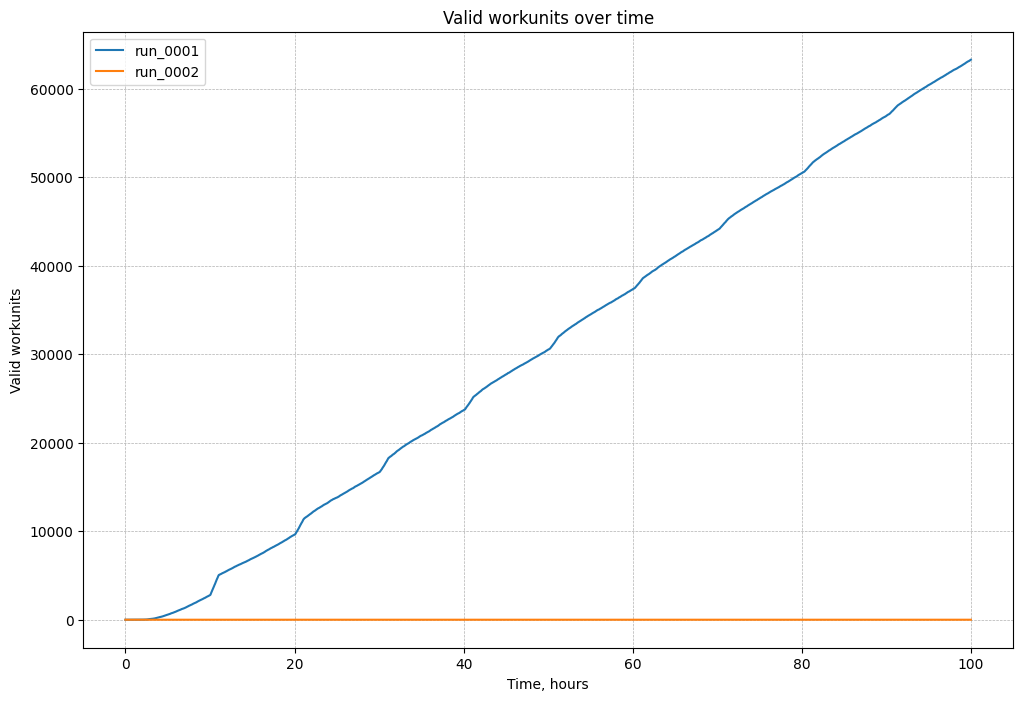

In [4]:
folders = sorted(
    f
    for f in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, f)) and f.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

fig, ax = plt.subplots(figsize=(12, 8))

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    task_dynamic_path = os.path.join(full_path, TASK_DYNAMIC_NAME)

    if not os.path.exists(task_dynamic_path):
        print(f"skip {folder}: {TASK_DYNAMIC_NAME} not found")
        continue

    plot_valid_workunits(ax, task_dynamic_path, folder)

ax.legend()
plt.show()
